In [1]:
import duckdb

quack_db = "./commitizen.duckdb"

with duckdb.connect(quack_db, read_only=True) as con:
    events_df = con.sql("SELECT * FROM main.events").df()

events_df


,id,event_type_id,timestamp,description
0,32,31,2026-03-20 03:10:56,create #1907
1,44,43,2026-03-20 03:10:41,committed (#1907)
2,55,54,2026-03-20 03:10:57,review_requested (#1907)
3,66,54,2026-03-20 03:10:57,review_requested (#1907)
4,77,76,2026-03-20 03:11:05,labeled (#1907)
...,...,...,...,...
25888,117173,124,2017-11-04 15:32:12,commented (#1)
25889,117177,105,2017-11-27 13:35:03,closed (#1)
25890,117180,1875,2021-08-13 13:07:29,referenced (#1)
25891,117183,1875,2022-02-07 07:50:58,referenced (#1)


In [2]:
#intervention commits messages
import duckdb
quack_db = "./commitizen.duckdb"

with duckdb.connect(quack_db, read_only=True) as con:
    objects_attributes = con.sql("SELECT * FROM main.object_attribute_values").df()

objects_attributes

,id,object_id,object_attribute_id,timestamp,attribute_value
0,28,27,5,2026-03-20 03:10:56,1907
1,29,27,6,2026-03-20 03:10:56,docs: the original link has been moved to new ...
2,30,27,7,2026-03-20 03:10:56,https://api.github.com/repos/commitizen-tools/...
3,37,36,8,2013-08-02 05:52:43,5144808
4,38,36,9,2013-08-02 05:52:43,Lee-W
...,...,...,...,...,...
16753,117162,117159,7,2017-11-04 11:09:22,https://api.github.com/repos/commitizen-tools/...
16754,117167,117166,8,2013-06-10 10:54:02,4660275
16755,117168,117166,9,2013-06-10 10:54:02,sobolevn
16756,117169,117166,10,2013-06-10 10:54:02,https://github.com/sobolevn


In [3]:
import duckdb

quack_db = "./commitizen.duckdb"

with duckdb.connect(quack_db, read_only=True) as con:
    eventsPerobj_df = con.sql("SELECT * FROM graph_data_prep.graph_base_table").df()

eventsPerobj_df


,event_node_id,event_id,event_description,event_type_id,event_type,event_timestamp,event_timestamp_node_id,snapshot_node_id,object_id,object_description,object_type_id,object_type,snapshot_timestamp,snapshot_timestamp_node_id,qualifier_id,qualifier_description,snapshot_dense_rank
0,event_80358,80358,labeled (#636),76,labeled,2022-12-09 15:24:52,2022-12-09 15:24:52,object_36_2022-12-09 15:24:52,36,user:5144808,2,user,2022-12-09 15:24:52,2022-12-09 15:24:52,22,actor,1516
1,event_81176,81176,labeled (#630),76,labeled,2022-12-09 15:24:59,2022-12-09 15:24:59,object_36_2022-12-09 15:24:59,36,user:5144808,2,user,2022-12-09 15:24:59,2022-12-09 15:24:59,22,actor,1517
2,event_80504,80504,reviewed (#633),94,reviewed,2022-12-09 15:28:27,2022-12-09 15:28:27,object_36_2022-12-09 15:28:27,36,user:5144808,2,user,2022-12-09 15:28:27,2022-12-09 15:28:27,22,actor,1518
3,event_80508,80508,commented (#633),124,commented,2022-12-09 15:30:52,2022-12-09 15:30:52,object_36_2022-12-09 15:30:52,36,user:5144808,2,user,2022-12-09 15:30:52,2022-12-09 15:30:52,22,actor,1519
4,event_80518,80518,review_requested (#633),54,review_requested,2022-12-09 15:31:05,2022-12-09 15:31:05,object_36_2022-12-09 15:31:05,36,user:5144808,2,user,2022-12-09 15:31:05,2022-12-09 15:31:05,22,actor,1520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57310,event_116676,116676,merged (#14),100,merged,2019-04-14 19:56:01,2019-04-14 19:56:01,object_116583_2019-04-14 19:56:01,116583,#14,1,issue,2019-04-14 19:56:01,2019-04-14 19:56:01,20,timeline_event,13
57311,event_116679,116679,closed (#14),105,closed,2019-04-14 19:56:01,2019-04-14 19:56:01,object_116583_2019-04-14 19:56:01,116583,#14,1,issue,2019-04-14 19:56:01,2019-04-14 19:56:01,20,timeline_event,13
57312,event_116682,116682,head_ref_deleted (#14),110,head_ref_deleted,2020-03-16 14:40:32,2020-03-16 14:40:32,object_116583_2020-03-16 14:40:32,116583,#14,1,issue,2020-03-16 14:40:32,2020-03-16 14:40:32,20,timeline_event,14
57313,event_116797,116797,committed (#11),43,committed,2019-04-02 09:39:55,2019-04-02 09:39:55,object_116799_2019-04-02 09:39:55,116799,sha:265d25ce494c4a8ea2de4b792ab7217897c92e80,4,commit,2019-04-02 09:39:55,2019-04-02 09:39:55,20,timeline_event,1


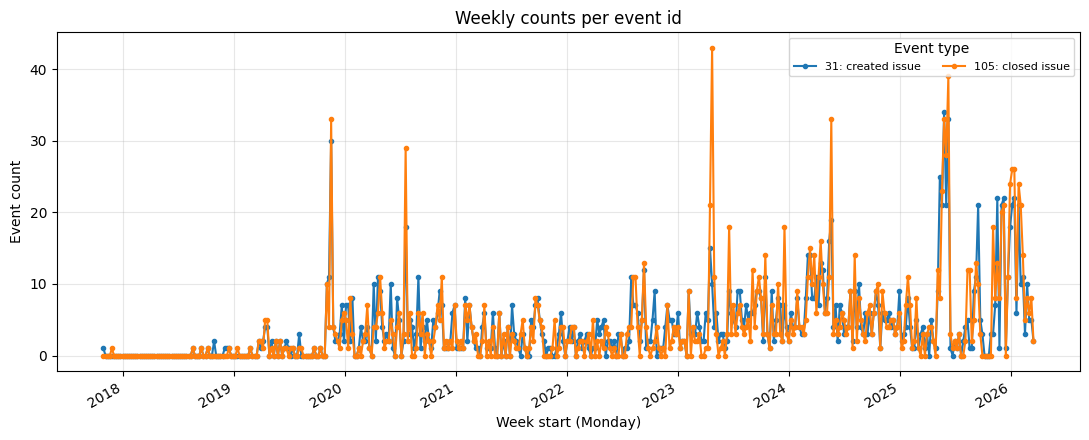

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

FIGURES_DIR = Path(".")

event_ids = [31, 105]#31 created, 43 committed, 105 closed
object_type = "issue"
event_labels = {
    31: "31: created issue",
    105: "105: closed issue",
}

sub = eventsPerobj_df.loc[eventsPerobj_df["event_type_id"].isin(event_ids) & eventsPerobj_df["object_type"].eq(object_type)	].copy()
ts = pd.to_datetime(sub["event_timestamp"])
sub["week_start"] = (ts - pd.to_timedelta(ts.dt.weekday, unit="D")).dt.normalize()

weekly = (
    sub.groupby(["week_start", "event_type_id"])
    .size()
    .unstack("event_type_id", fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 4.5))
if weekly.empty:
    ax.text(
        0.5,
        0.5,
        "No rows for these event id values",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
else:
    weeks = pd.date_range(weekly.index.min(), weekly.index.max(), freq="7D")
    for eid in event_ids:
        s = weekly[eid] if eid in weekly.columns else pd.Series(dtype=int)
        y = s.reindex(weeks, fill_value=0)
        ax.plot(weeks, y.values, marker="o", markersize=3, label=event_labels.get(eid, str(eid)))
    ax.legend(title="Event type", ncol=2, fontsize=8)

ax.set_xlabel("Week start (Monday)")
ax.set_ylabel("Event count")
ax.set_title("Weekly counts per event id")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "weekly_event_counts.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
# Rolling IQR anomaly detection plus text-state extraction
#  for weekly[105] as closed_issues rate representing vital sign and object_attribute_id 6 as title representing state
import re
from collections import Counter
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = Path()

ANOMALY_EVENT_TYPE_ID = 105
ANOMALY_OBJECT_TYPE = "issue"
VALID_SEVERITIES = {"P0", "P1", "P2", "P3", "P4"}

IQR_CONFIG = {
    "window_size": 30,
    "min_periods": 8,
    "iqr_multiplier": 1.5,
}


def _week_start(values):
    ts = pd.to_datetime(values)
    return (ts - pd.to_timedelta(ts.dt.weekday, unit="D")).dt.normalize()


def rolling_iqr_detect(series, window_size=30, min_periods=8, iqr_multiplier=1.5):
    """Detect point anomalies with a backward-looking rolling IQR window."""
    clean = pd.to_numeric(series, errors="coerce").sort_index()
    clean.index = pd.to_datetime(clean.index)
    clean = clean.groupby(clean.index).sum().sort_index()

    history = clean.shift(1).rolling(window=window_size, min_periods=min_periods)
    q1 = history.quantile(0.25)
    q3 = history.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr

    is_low = clean < lower
    is_high = clean > upper
    nonzero_iqr = iqr.replace(0, np.nan)
    high_distance = (clean - upper).clip(lower=0)
    low_distance = (lower - clean).clip(lower=0)
    anomaly_score = ((high_distance + low_distance) / nonzero_iqr).fillna(0)

    return pd.DataFrame(
        {
            "week_start": clean.index,
            "value": clean.values,
            "rolling_q1": q1.values,
            "rolling_q3": q3.values,
            "iqr": iqr.values,
            "lower_bound": lower.values,
            "upper_bound": upper.values,
            "is_anomaly": (is_low | is_high).fillna(False).values,
            "anomaly_direction": np.select(
                [is_high.fillna(False), is_low.fillna(False)],
                ["high", "low"],
                default="normal",
            ),
            "anomaly_score": anomaly_score.values,
        }
    )


def build_weekly_titles_for_105(eventsPerobj_df, objects_attributes, event_type_id=ANOMALY_EVENT_TYPE_ID):
    events_105_objects = eventsPerobj_df.loc[
        eventsPerobj_df["event_type_id"].eq(event_type_id) & eventsPerobj_df["object_type"].eq(ANOMALY_OBJECT_TYPE)	
    ].copy()
    events_105_objects["week_start"] = _week_start(events_105_objects["event_timestamp"])
    events_105_objects["object_id_key"] = pd.to_numeric(
        events_105_objects["object_id"], errors="coerce"
    ).astype("Int64")

    title_attributes = objects_attributes.loc[
        objects_attributes["object_attribute_id"].eq(6) #object_attribute_id 6 as title of issues
    ].copy()
    title_attributes["object_id_key"] = pd.to_numeric(
        title_attributes["object_id"], errors="coerce"
    ).astype("Int64")
    title_cols = ["object_id_key", "object_id", "object_attribute_id", "attribute_value"]
    if "timestamp" in title_attributes.columns:
        title_cols.append("timestamp")

    joined = events_105_objects.merge(
        title_attributes[title_cols],
        on="object_id_key",
        how="left",
        suffixes=("_event_object", "_attribute"),
    )

    fallback_text = joined.get("object_description", pd.Series("", index=joined.index))
    joined["title_text"] = joined["attribute_value"].fillna(fallback_text)

    def unique_nonempty(values):
        seen = []
        for value in values.dropna().astype(str):
            value = value.strip()
            if value and value not in seen:
                seen.append(value)
        return seen

    weekly_text = (
        joined.groupby("week_start")
        .agg(
            event_count=("event_id", "nunique"),
            title_count=("attribute_value", lambda s: s.dropna().nunique()),
            titles_in_week=("title_text", unique_nonempty),
            event_descriptions=("event_description", unique_nonempty),
            event_ids=("event_id", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
            object_ids=("object_id_key", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
        )
        .reset_index()
    )
    weekly_text["titles_text"] = weekly_text["titles_in_week"].apply(lambda titles: "\n".join(titles))
    return weekly_text, joined


SEVERITY_PATTERNS = {
    "P0": [
        r"\boutage(s)?\b",
        r"\bdowntime\b",
        r"\bdata\s*loss\b",
        r"\bcorrupt(ed|ion)?\b",
        r"\bsecurity\s*(breach|incident|advisory)\b",
        r"\b(cve|vulnerabilit(y|ies)|exploit|rce)\b",
        r"\bproduction\s*(down|broken|outage)\b",
        r"\b(panic|deadlock|hang|hangs|hanging)\b",
        r"\bdata\s*corruption\b",
    ],
    "P1": [
        r"\bblocker\b",
        r"\bcritical\b",
        r"\burgent\b",
        r"\bregression\b",
        r"\bsevere\b",
        r"\bhotfix\b",
        r"\bincident\b",
        r"\b(broken|completely\s*broken|cannot|can\'?t|unable\s*to)\b",
        r"\b(fails?|failure|failed|failing)\b",
    ],
    "P2": [
        r"\bbug\b",
        r"\b(fix(es|ed|ing)?)\b",
        r"\b(error|errors)\b",
        r"\bexception(s)?\b",
        r"\bflaky\b",
        r"\b(timeout|time\s*out)\b",
        r"\bdegrade(d|s)?\b",
        r"\b(slow|latency|performance)\b",
        r"\b(memory\s*leak|leak)\b",
    ],
    "P3": [
        r"\brefactor(s|ing|ed)?\b",
        r"\bcleanup\b",
        r"\b(improve|improvement|enhance(ment)?)\b",
        r"\bsimplif(y|ies|ied)\b",
        r"\bpolish\b",
        r"\brestructur(e|ing)\b",
        r"\bchore\b",
        r"\b(test|tests|testing)\b",
        r"\bbuild\b",
        r"\b(ci|pipeline|workflow|github\s*actions?)\b",
    ],
    "P4": [
        r"\b(typo|typos)\b",
        r"\b(style|styling|format(ting)?|lint(ing)?)\b",
        r"\bgrammar\b",
        r"\bcomment(s)?\b",
        r"\b(docs?|documentation|readme|changelog)\b",
        r"\b(bump|bumps|bumped)\b",
        r"\b(dependency|dependencies|deps)\b",
        r"\b(version|versions|semver)\b",
        
        
    ],
}

SEVERITY_PRIORITY = ["P0", "P1", "P2", "P3", "P4"]

COMPONENT_PATTERNS = {
    "documentation": [
        r"\b(docs?|documentation|readme|guide|manual|tutorial|examples?|changelog)\b",
    ],
    "testing": [
        r"\b(tests?|testing|pytest|unittest|fixture|mock(s|ed|ing)?|spec|coverage|flaky)\b",
    ],
    "build & ci": [
        r"\b(build|ci|pipeline|workflow|github\s*actions?|release|deploy(ment)?|packaging|makefile|tox|nox)\b",
    ],
    "dependencies": [
        r"\b(dependency|dependencies|deps|package|requirements?|poetry|pip|lockfile|pyproject|pip-?tools?)\b",
    ],
    "version & bump": [
        r"\b(bump(s|ed|ing)?|version(s|ing)?|semver|release\s*notes?|tag(s|ged|ging)?)\b",
    ],
    
    "configuration": [
        r"\b(config(uration)?|settings|toml|yaml|yml|ini|\.env|dotenv|pyproject\.toml)\b",
    ],
    "cli interface": [
        r"\b(cli|command\s*line|argument(s)?|flag(s)?|option(s)?|subcommand|prompt)\b",
    ],
    "git integration": [
        r"\b(git|branch(es)?|rebase|merge|hook(s)?|push|pull|cross[-\s]*reference|reference)\b",
    ],
    "api & endpoints": [
        r"\b(api|endpoint(s)?|request(s)?|response(s)?|client|server|http|rest|graphql)\b",
    ],
    "user interface": [
        r"\b(ui|frontend|view|button|page|screen|layout|css|theme)\b",
    ],
    "database & schema": [
        r"\b(database|db|sql|migration|schema|query|orm|sqlalchemy|sqlite)\b",
    ],
    "authentication": [
        r"\b(auth|login|token|permission|access|oauth|jwt|credentials?)\b",
    ],
    "runtime stability": [
        r"\b(error|exception|crash|timeout|leak|hang|panic|traceback|stacktrace)\b",
    ],
    "performance": [
        r"\b(performance|slow|latency|throughput|optimi[sz]ation|speed|memory)\b",
    ],
    "internationalization": [
        r"\b(i18n|l10n|translation|locale|language\s*support)\b",
    ],
    "logging & telemetry": [
        r"\b(log(ging)?|telemetry|metrics?|monitoring|trace(s)?)\b",
    ],
    "templates & rendering": [
        r"\b(template(s)?|render(ing)?|jinja|markup|markdown|mkdocs)\b",
    ],
}

STOPWORDS = {
    "the", "and", "for", "with", "from", "this", "that", "into", "when", "week",
    "issue", "issues", "closed", "close", "make", "made", "via", "use", "using",
    "add", "adds", "added", "adding", "update", "updates", "updated",
    "support", "supports", "supported", "allow", "allows", "remove", "removes",
    "removed", "change", "changes", "changed", 
    "request", "merge", "merged", "open", "opened", "init", "main",
}


def _count_pattern_hits(text, pattern_groups):
    lowered = text.lower()
    scores = {}
    for label, patterns in pattern_groups.items():
        total = 0
        for pattern in patterns:
            total += len(re.findall(pattern, lowered))
        if total:
            scores[label] = total
    return scores


def _top_terms(text, limit=4):
    tokens = re.findall(r"[a-zA-Z][a-zA-Z0-9_-]{2,}", text.lower())
    counts = Counter(t for t in tokens if t not in STOPWORDS and len(t) > 2)
    return [term for term, _ in counts.most_common(limit)]


def _limit_component_words(component, max_words=4):
    words = str(component).strip().split()
    return " ".join(words[:max_words]) if words else "unknown area"


def _humanize_score(score):
    score = float(score or 0)
    if score >= 3.0:
        return "well beyond"
    if score >= 1.5:
        return "clearly beyond"
    if score >= 0.5:
        return "slightly beyond"
    return "near"


def _pick_severity(severity_scores, anomaly_score, direction, title_count):
    if severity_scores:
        ranked = sorted(
            severity_scores.items(),
            key=lambda item: (item[1], -SEVERITY_PRIORITY.index(item[0])),
            reverse=True,
        )
        return ranked[0][0], True

    if anomaly_score >= 3.0:
        return "P1", False
    if anomaly_score >= 1.5:
        return "P2", False
    if anomaly_score >= 0.5:
        return "P3", False
    if direction == "low" and title_count == 0:
        return "P4", False
    return "P3", False


def _pick_component(component_scores):
    if not component_scores:
        return "unknown area", 0.0
    ranked = sorted(component_scores.items(), key=lambda item: item[1], reverse=True)
    label, hits = ranked[0]
    return _limit_component_words(label), float(hits)


def _compute_lexicon_confidence(severity, severity_scores, component_scores, title_count, severity_from_text):
    sev_hits = severity_scores.get(severity, 0)
    total_sev = sum(severity_scores.values())
    sev_share = sev_hits / total_sev if total_sev else 0.0

    comp_hits = max(component_scores.values(), default=0)
    total_comp = sum(component_scores.values())
    comp_share = comp_hits / total_comp if total_comp else 0.0

    if total_sev and total_comp:
        dominance = 0.7 * sev_share + 0.3 * comp_share
    elif total_sev:
        dominance = sev_share
    elif total_comp:
        dominance = comp_share
    else:
        dominance = 0.0

    confidence = 0.30 + 0.65 * dominance
    if title_count:
        confidence = min(confidence + 0.05, 0.95)
    if not severity_from_text:
        confidence = max(confidence - 0.10, 0.30)
    return max(0.30, min(confidence, 0.95))


def _build_reasoning(direction, value, lower_bound, upper_bound, anomaly_score,
                     component, component_scores, severity_scores, top_terms,
                     title_count, event_count):
    band_text = ""
    try:
        if direction == "high" and pd.notna(upper_bound):
            band_text = f" ({int(value)} vs upper bound {upper_bound:.0f})"
        elif direction == "low" and pd.notna(lower_bound):
            band_text = f" ({int(value)} vs lower bound {lower_bound:.0f})"
    except Exception:
        band_text = ""

    movement = "spike" if direction == "high" else ("drop" if direction == "low" else "shift")
    magnitude = _humanize_score(anomaly_score)
    top_components = [c for c, _ in sorted(component_scores.items(), key=lambda kv: kv[1], reverse=True)[:2]]
    components_phrase = component if not top_components else ", ".join(top_components[:2])
    severity_signals = sorted(severity_scores.keys(), key=SEVERITY_PRIORITY.index)[:2]

    parts = [
        f"Weekly closures show a {magnitude}-typical {movement}{band_text}",
    ]
    if title_count:
        parts.append(f"covering {title_count} unique titles across {event_count} events")
    if components_phrase:
        parts.append(f"focused on {components_phrase}")
    if top_terms:
        parts.append(f"with recurring terms like {', '.join(top_terms)}")
    if severity_signals and (severity_signals != ["P3"]):
        parts.append(f"flagged by {'/'.join(severity_signals)} signal words")

    sentence = ", ".join(parts).rstrip(",")
    if sentence and sentence[-1] not in ".!?":
        sentence += "."
    return sentence


def extract_state_rule_based(row):
    text = str(row.get("titles_text", ""))
    severity_scores = _count_pattern_hits(text, SEVERITY_PATTERNS)
    component_scores = _count_pattern_hits(text, COMPONENT_PATTERNS)
    anomaly_score = float(row.get("anomaly_score", 0) or 0)
    direction = row.get("anomaly_direction", "normal")
    title_count = int(row.get("title_count", 0) or 0)
    event_count = int(row.get("event_count", 0) or 0)
    value = row.get("value", 0)
    lower_bound = row.get("lower_bound", float("nan"))
    upper_bound = row.get("upper_bound", float("nan"))

    severity, severity_from_text = _pick_severity(
        severity_scores, anomaly_score, direction, title_count,
    )
    component, _ = _pick_component(component_scores)
    confidence = _compute_lexicon_confidence(
        severity, severity_scores, component_scores, title_count, severity_from_text,
    )

    top_terms = _top_terms(text)

    reasoning = _build_reasoning(
        direction=direction,
        value=value,
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        anomaly_score=anomaly_score,
        component=component,
        component_scores=component_scores,
        severity_scores=severity_scores,
        top_terms=top_terms,
        title_count=title_count,
        event_count=event_count,
    )

    return {
        "severity": severity,
        "component": component,
        "reasoning": reasoning,
        "extraction_method": "rule_based",
        "confidence": confidence,
    }


weekly_105_anomaly_frame = rolling_iqr_detect(weekly[ANOMALY_EVENT_TYPE_ID], **IQR_CONFIG)
weekly_105_titles, event_105_title_join = build_weekly_titles_for_105(
    eventsPerobj_df,
    objects_attributes,
    event_type_id=ANOMALY_EVENT_TYPE_ID,
)

anomaly_context = weekly_105_anomaly_frame.loc[weekly_105_anomaly_frame["is_anomaly"]].merge(
    weekly_105_titles,
    on="week_start",
    how="left",
)
anomaly_context["title_count"] = anomaly_context["title_count"].fillna(0).astype(int)
anomaly_context["event_count"] = anomaly_context["event_count"].fillna(0).astype(int)
anomaly_context["titles_in_week"] = anomaly_context["titles_in_week"].apply(
    lambda value: value if isinstance(value, list) else []
)
anomaly_context["event_descriptions"] = anomaly_context["event_descriptions"].apply(
    lambda value: value if isinstance(value, list) else []
)
anomaly_context["titles_text"] = anomaly_context["titles_text"].fillna("")

state_columns = ["severity", "component", "reasoning", "extraction_method", "confidence"]
if anomaly_context.empty:
    state_rows = pd.DataFrame(columns=state_columns)
else:
    state_rows = anomaly_context.apply(
        lambda row: extract_state_rule_based(row),
        axis=1,
        result_type="expand",
    ).reindex(columns=state_columns)

anomaly_states = pd.concat([anomaly_context.reset_index(drop=True), state_rows], axis=1)

expected_columns = [
    "week_start",
    "value",
    "is_anomaly",
    "anomaly_direction",
    "anomaly_score",
    "lower_bound",
    "upper_bound",
    "title_count",
    "event_count",
    "severity",
    "component",
    "reasoning",
    "extraction_method",
    "confidence",
    "event_descriptions",
    "titles_in_week",
]
anomaly_states = anomaly_states.reindex(columns=expected_columns).sort_values("week_start")

if not anomaly_states.empty:
    assert anomaly_states["severity"].isin(VALID_SEVERITIES).all(), "Invalid severity found."
    assert anomaly_states["component"].astype(str).str.split().str.len().le(4).all(), "Component exceeds 4 words."
    assert anomaly_states["reasoning"].astype(str).str.len().gt(0).all(), "Missing reasoning found."
    assert len(anomaly_states) == int(weekly_105_anomaly_frame["is_anomaly"].sum()), "Anomaly row count mismatch."

print(f"Detected {len(anomaly_states)} rolling-IQR anomalies for event_type_id={ANOMALY_EVENT_TYPE_ID}.")
print(
    "Joined title attribute rows: "
    f"{event_105_title_join['attribute_value'].notna().sum()} of {len(event_105_title_join)} event rows."
)

anomaly_states_csv_path = "anomaly_states.csv"
anomaly_states.to_csv(anomaly_states_csv_path, index=False)
print(f"Saved anomaly states to {anomaly_states_csv_path}")
anomaly_context.to_csv("anomaly_context.csv", index=False)




Detected 25 rolling-IQR anomalies for event_type_id=105.
Joined title attribute rows: 1729 of 1729 event rows.
Saved anomaly states to anomaly_states.csv


In [6]:
def build_anomaly_object_ids(anomaly_context):
    return (
        anomaly_context[["week_start", "object_ids"]]
        .explode("object_ids")
        .rename(columns={"object_ids": "object_id"})
        .dropna(subset=["object_id"])
        .drop_duplicates()
        .reset_index(drop=True)
    )
anomaly_object_ids = build_anomaly_object_ids(anomaly_context)
anomaly_object_ids.to_csv("anomaly_object_ids.csv", index=False)

In [7]:
def build_anomaly_event_ids(anomaly_context):
    return (
        anomaly_context[["week_start", "event_ids"]]
        .explode("event_ids")
        .rename(columns={"event_ids": "event_id"})
        .dropna(subset=["event_id"])
        .drop_duplicates()
        .reset_index(drop=True)
    )
anomaly_event_ids = build_anomaly_event_ids(anomaly_context)
anomaly_event_ids.to_csv("anomaly_event_ids.csv", index=False)

### Plot figures

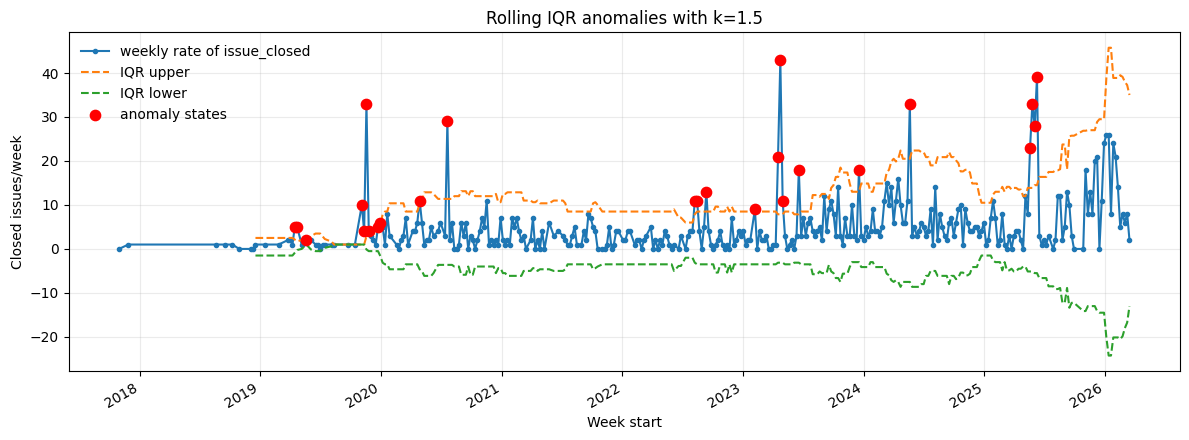

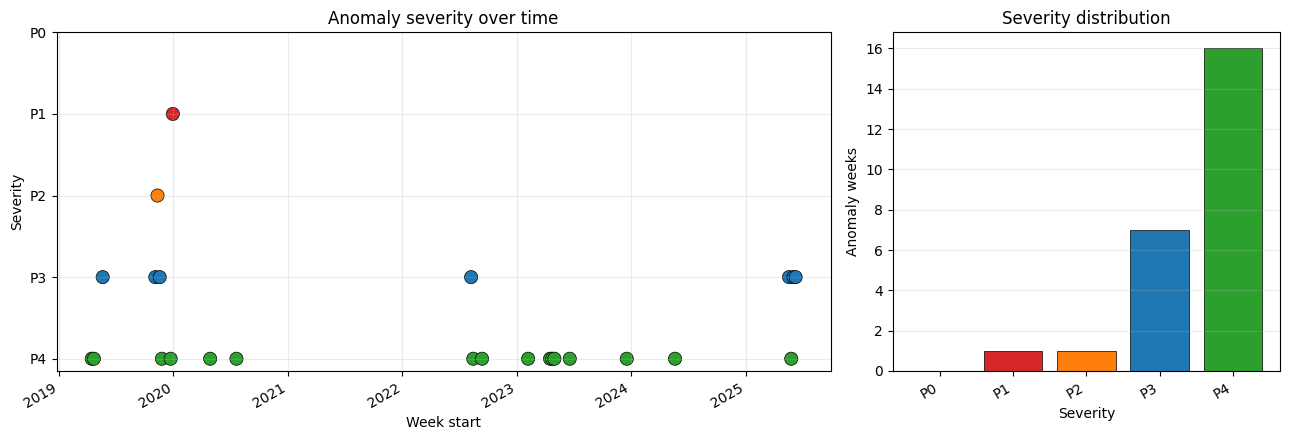

C:\Users\mahsa.choopannezhadm\AppData\Local\Temp\ipykernel_2080\4057328643.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


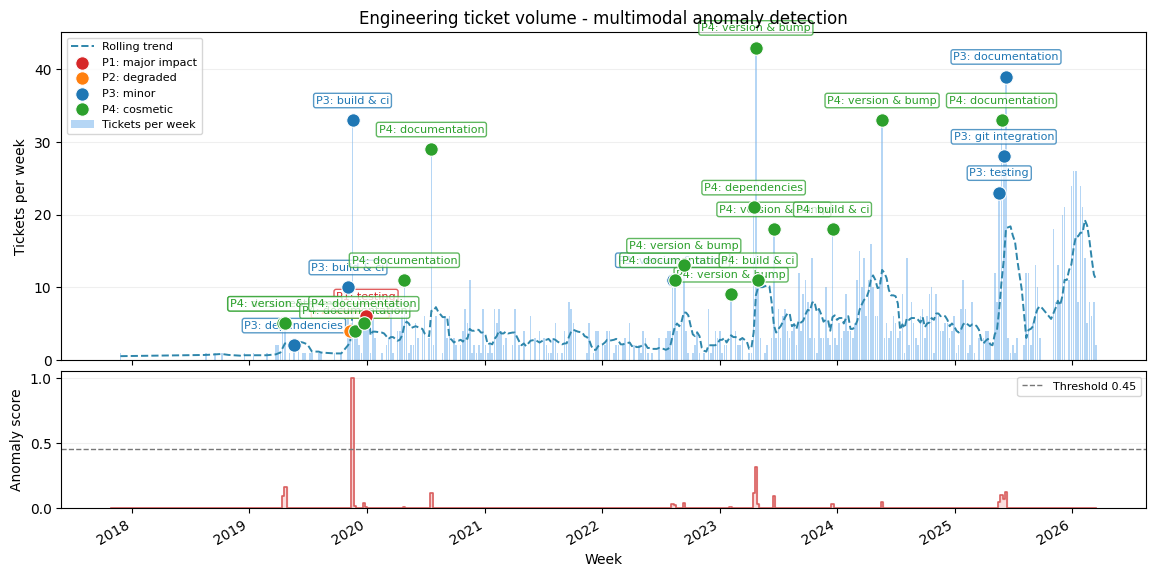

C:\Users\mahsa.choopannezhadm\AppData\Local\Temp\ipykernel_2080\4057328643.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


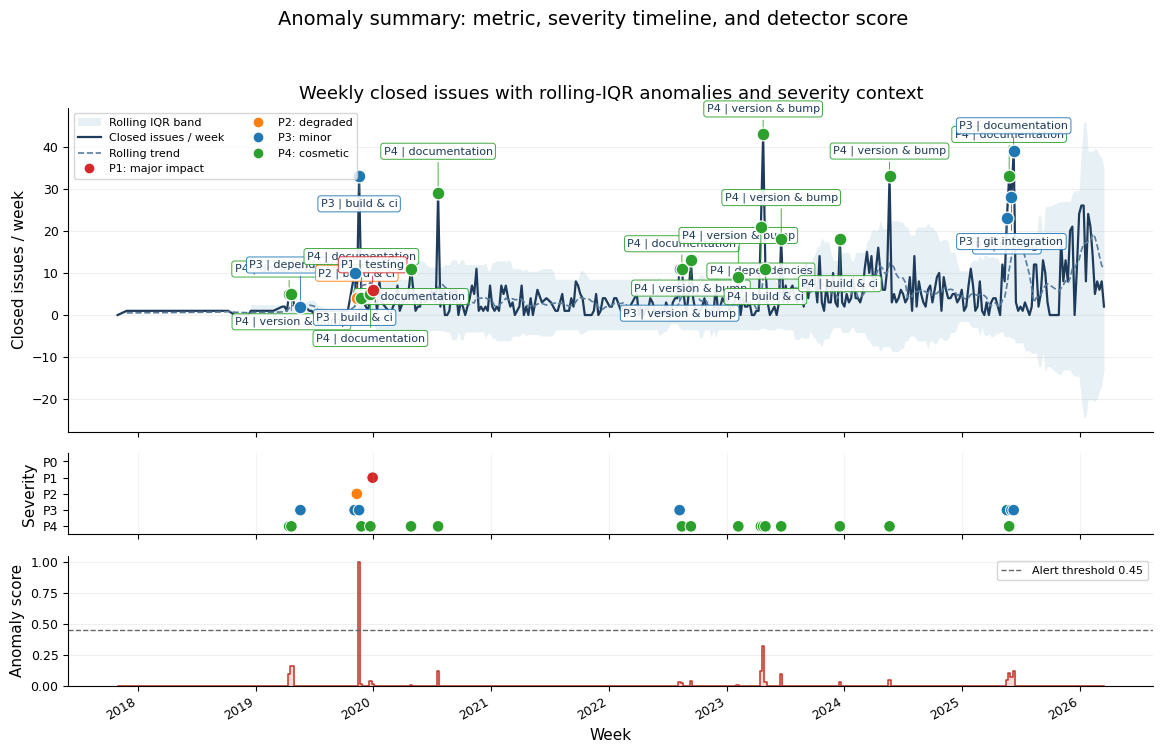

In [8]:

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(
    weekly_105_anomaly_frame["week_start"],
    weekly_105_anomaly_frame["value"],
    marker="o",
    markersize=3,
    label="weekly rate of issue_closed",
)
ax.plot(weekly_105_anomaly_frame["week_start"], weekly_105_anomaly_frame["upper_bound"], linestyle="--", label="IQR upper")
ax.plot(weekly_105_anomaly_frame["week_start"], weekly_105_anomaly_frame["lower_bound"], linestyle="--", label="IQR lower")
if not anomaly_states.empty:
    ax.scatter(
        anomaly_states["week_start"],
        anomaly_states["value"],
        color="red",
        s=55,
        zorder=3,
        label="anomaly states",
    )
ax.set_title("Rolling IQR anomalies with k=1.5")
ax.set_xlabel("Week start")
ax.set_ylabel("Closed issues/week")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "rolling_iqr_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

severity_order = ["P0", "P1", "P2", "P3", "P4"]
severity_to_level = {severity: idx for idx, severity in enumerate(severity_order)}
severity_colors = {
    "P0": "#8B0000",
    "P1": "#D62728",
    "P2": "#FF7F0E",
    "P3": "#1F77B4",
    "P4": "#2CA02C",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})
if anomaly_states.empty:
    axes[0].text(0.5, 0.5, "No anomaly severity states", ha="center", va="center", transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, "No severity counts", ha="center", va="center", transform=axes[1].transAxes)
else:
    severity_plot = anomaly_states.copy()
    severity_plot["severity_level"] = severity_plot["severity"].map(severity_to_level)
    axes[0].scatter(
        severity_plot["week_start"],
        severity_plot["severity_level"],
        s=90,
        c=severity_plot["severity"].map(severity_colors),
        edgecolor="black",
        linewidth=0.5,
    )
    axes[0].set_yticks(range(len(severity_order)))
    axes[0].set_yticklabels(severity_order)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Week start")
    axes[0].set_ylabel("Severity")
    axes[0].set_title("Anomaly severity over time")
    axes[0].grid(alpha=0.25)

    severity_counts = severity_plot["severity"].value_counts().reindex(severity_order, fill_value=0)
    axes[1].bar(
        severity_counts.index,
        severity_counts.values,
        color=[severity_colors[severity] for severity in severity_counts.index],
        edgecolor="black",
        linewidth=0.5,
    )
    axes[1].set_xlabel("Severity")
    axes[1].set_ylabel("Anomaly weeks")
    axes[1].set_title("Severity distribution")
    axes[1].grid(axis="y", alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "anomaly_severity_overview.png", dpi=150, bbox_inches="tight")
plt.show()

severity_legend_labels = {
    "P0": "P0: complete outage",
    "P1": "P1: major impact",
    "P2": "P2: degraded",
    "P3": "P3: minor",
    "P4": "P4: cosmetic",
}
plot_frame = weekly_105_anomaly_frame.copy().sort_values("week_start")
plot_frame["rolling_trend"] = plot_frame["value"].rolling(window=8, min_periods=2).mean()
score_max = plot_frame["anomaly_score"].max()
if pd.isna(score_max) or score_max <= 0:
    plot_frame["anomaly_score_scaled"] = 0.0
else:
    plot_frame["anomaly_score_scaled"] = (plot_frame["anomaly_score"] / score_max).clip(0, 1)

score_threshold = 0.45
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.25], "hspace": 0.05},
)

axes[0].bar(
    plot_frame["week_start"],
    plot_frame["value"],
    width=5,
    color="#9CC9F2",
    alpha=0.75,
    label="Tickets per week",
)
axes[0].plot(
    plot_frame["week_start"],
    plot_frame["rolling_trend"],
    color="#2E86AB",
    linestyle="--",
    linewidth=1.4,
    label="Rolling trend",
)

for severity in severity_order:
    subset = anomaly_states.loc[anomaly_states["severity"].eq(severity)].copy()
    if subset.empty:
        continue
    axes[0].scatter(
        subset["week_start"],
        subset["value"],
        color=severity_colors[severity],
        edgecolor="white",
        linewidth=0.8,
        s=95,
        zorder=4,
        label=severity_legend_labels[severity],
    )
    for _, row in subset.iterrows():
        label = f"{row['severity']}: {row['component']}"
        axes[0].annotate(
            label,
            xy=(row["week_start"], row["value"]),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=severity_colors[severity],
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": severity_colors[severity], "alpha": 0.75},
        )

axes[0].set_title("Engineering ticket volume - multimodal anomaly detection")
axes[0].set_ylabel("Tickets per week")
axes[0].grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper left", fontsize=8, frameon=True)

axes[1].fill_between(
    plot_frame["week_start"],
    plot_frame["anomaly_score_scaled"],
    step="mid",
    color="#F3A6A6",
    alpha=0.35,
)
axes[1].plot(
    plot_frame["week_start"],
    plot_frame["anomaly_score_scaled"],
    color="#D95F5F",
    linewidth=1.2,
    drawstyle="steps-mid",
)
axes[1].axhline(score_threshold, color="#777777", linestyle="--", linewidth=1, label=f"Threshold {score_threshold:.2f}")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Anomaly score")
axes[1].set_xlabel("Week")
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(loc="upper right", fontsize=8, frameon=True)

fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ticket_volume_anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()


with plt.rc_context({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}):
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 8.5),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1, 1.6], "hspace": 0.12},
    )

    metric_ax, severity_ax, score_ax = axes
    metric_ax.fill_between(
        plot_frame["week_start"],
        plot_frame["lower_bound"],
        plot_frame["upper_bound"],
        color="#B8D4E3",
        alpha=0.35,
        label="Rolling IQR band",
        linewidth=0,
    )
    metric_ax.plot(
        plot_frame["week_start"],
        plot_frame["value"],
        color="#1F3B5B",
        linewidth=1.6,
        label="Closed issues / week",
    )
    metric_ax.plot(
        plot_frame["week_start"],
        plot_frame["rolling_trend"],
        color="#5A7C9C",
        linestyle="--",
        linewidth=1.2,
        label="Rolling trend",
    )

    annotated_states = anomaly_states.dropna(subset=["week_start", "value"]).copy()
    annotated_states = annotated_states.sort_values("week_start")
    label_offsets = [(0, 16), (0, -22), (0, 28), (0, -34)]
    for plot_index, (_, row) in enumerate(annotated_states.iterrows()):
        severity = row["severity"]
        color = severity_colors.get(severity, "#444444")
        metric_ax.scatter(
            row["week_start"],
            row["value"],
            color=color,
            edgecolor="white",
            linewidth=0.9,
            s=85,
            zorder=4,
        )
        offset = label_offsets[plot_index % len(label_offsets)]
        metric_ax.annotate(
            f"{severity} | {row['component']}",
            xy=(row["week_start"], row["value"]),
            xytext=offset,
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#1F3B5B",
            arrowprops={"arrowstyle": "-", "color": color, "lw": 0.6},
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": color, "lw": 0.7, "alpha": 0.9},
        )

    metric_ax.set_title("Weekly closed issues with rolling-IQR anomalies and severity context")
    metric_ax.set_ylabel("Closed issues / week")
    metric_ax.grid(axis="y", alpha=0.2)
    handles, labels = metric_ax.get_legend_handles_labels()
    severity_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=severity_colors[s], markeredgecolor="white",
                   markersize=8, label=severity_legend_labels[s])
        for s in severity_order
        if s in set(annotated_states["severity"])
    ]
    metric_ax.legend(handles + severity_handles, labels + [h.get_label() for h in severity_handles],
                     loc="upper left", fontsize=8, ncol=2, frameon=True)

    severity_ax.set_yticks(range(len(severity_order)))
    severity_ax.set_yticklabels(severity_order)
    severity_ax.invert_yaxis()
    severity_ax.set_ylim(len(severity_order) - 0.5, -0.5)
    severity_ax.set_ylabel("Severity")
    severity_ax.grid(axis="x", alpha=0.15)
    if not annotated_states.empty:
        annotated_states["severity_level"] = annotated_states["severity"].map(severity_to_level)
        severity_ax.scatter(
            annotated_states["week_start"],
            annotated_states["severity_level"],
            c=annotated_states["severity"].map(severity_colors),
            edgecolor="white",
            linewidth=0.7,
            s=70,
        )

    score_ax.fill_between(
        plot_frame["week_start"],
        plot_frame["anomaly_score_scaled"],
        step="mid",
        color="#F3A6A6",
        alpha=0.4,
    )
    score_ax.plot(
        plot_frame["week_start"],
        plot_frame["anomaly_score_scaled"],
        color="#C0392B",
        linewidth=1.1,
        drawstyle="steps-mid",
    )
    score_ax.axhline(
        score_threshold,
        color="#666666",
        linestyle="--",
        linewidth=1,
        label=f"Alert threshold {score_threshold:.2f}",
    )
    score_ax.set_ylim(0, 1.05)
    score_ax.set_ylabel("Anomaly score")
    score_ax.set_xlabel("Week")
    score_ax.grid(axis="y", alpha=0.2)
    score_ax.legend(loc="upper right", fontsize=8, frameon=True)

    fig.suptitle("Anomaly summary: metric, severity timeline, and detector score", fontsize=14, y=0.995)
    fig.autofmt_xdate()
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    fig.savefig(FIGURES_DIR / "anomaly_summary_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()

# Intervention analysis
context of comits to realize about vitalizing process

In [9]:
# Weekly commit-message context for anomaly weeks
# Anomaly weeks are picked from event_type_id=105 (issue closures) via weekly_105_anomaly_frame.
# Within those weeks, we aggregate commit messages from event_type_id=43, object_type="commit",
# joined to object_attribute_id=18 (commit message text).
COMMIT_EVENT_TYPE_ID = 43
COMMIT_OBJECT_TYPE = "commit"
COMMIT_MESSAGE_ATTRIBUTE_ID = 18


def build_weekly_commitmessages_for_43(eventsPerobj_df, objects_attributes, event_type_id=COMMIT_EVENT_TYPE_ID):
    events_43_objects = eventsPerobj_df.loc[
        eventsPerobj_df["event_type_id"].eq(event_type_id) & eventsPerobj_df["object_type"].eq(COMMIT_OBJECT_TYPE)
    ].copy()
    events_43_objects["week_start"] = _week_start(events_43_objects["event_timestamp"])
    events_43_objects["object_id_key"] = pd.to_numeric(
        events_43_objects["object_id"], errors="coerce"
    ).astype("Int64")

    message_attributes = objects_attributes.loc[
        objects_attributes["object_attribute_id"].eq(COMMIT_MESSAGE_ATTRIBUTE_ID)  # object_attribute_id 18 as commit message
    ].copy()
    message_attributes["object_id_key"] = pd.to_numeric(
        message_attributes["object_id"], errors="coerce"
    ).astype("Int64")
    msg_cols = ["object_id_key", "object_id", "object_attribute_id", "attribute_value"]
    if "timestamp" in message_attributes.columns:
        msg_cols.append("timestamp")

    joined = events_43_objects.merge(
        message_attributes[msg_cols],
        on="object_id_key",
        how="left",
        suffixes=("_event_object", "_attribute"),
    )

    fallback_text = joined.get("object_description", pd.Series("", index=joined.index))
    joined["message_text"] = joined["attribute_value"].fillna(fallback_text)

    def unique_nonempty(values):
        seen = []
        for value in values.dropna().astype(str):
            value = value.strip()
            if value and value not in seen:
                seen.append(value)
        return seen

    weekly_messages = (
        joined.groupby("week_start")
        .agg(
            commit_event_count=("event_id", "nunique"),
            message_count=("attribute_value", lambda s: s.dropna().nunique()),
            messages_in_week=("message_text", unique_nonempty),
            commit_event_descriptions=("event_description", unique_nonempty),
            commit_event_ids=("event_id", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
            commit_object_ids=("object_id_key", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
        )
        .reset_index()
    )
    weekly_messages["messages_text"] = weekly_messages["messages_in_week"].apply(lambda msgs: "\n".join(msgs))
    return weekly_messages, joined


weekly_43_messages, event_43_message_join = build_weekly_commitmessages_for_43(
    eventsPerobj_df,
    objects_attributes,
    event_type_id=COMMIT_EVENT_TYPE_ID,
)

commit_context = (
    weekly_105_anomaly_frame.loc[weekly_105_anomaly_frame["is_anomaly"]]
    .merge(weekly_43_messages, on="week_start", how="left")
)
commit_context["commit_event_count"] = commit_context["commit_event_count"].fillna(0).astype(int)
commit_context["message_count"] = commit_context["message_count"].fillna(0).astype(int)
commit_context["messages_in_week"] = commit_context["messages_in_week"].apply(
    lambda value: value if isinstance(value, list) else []
)
commit_context["commit_event_descriptions"] = commit_context["commit_event_descriptions"].apply(
    lambda value: value if isinstance(value, list) else []
)
commit_context["messages_text"] = commit_context["messages_text"].fillna("")

commit_context_csv_path = "commit_context.csv"
commit_context.to_csv(commit_context_csv_path, index=False)

n_rows, n_cols = commit_context.shape
print(f"commit_context summary: {n_rows} rows x {n_cols} columns")
print(f"Saved commit_context to {commit_context_csv_path}")

commit_context summary: 25 rows x 17 columns
Saved commit_context to commit_context.csv


# Commit type classification (per anomaly week)

Categorizes every commit message in `commit_context.messages_in_week` by its **Conventional Commit** type and rolls those types up into three high-level categories so each anomaly week gets a ratio of feature work vs bug fixes vs tech debt.

**Type detection** — regex on each message:

```
^(feat|fix|chore|docs|style|refactor|test|build|ci|perf|revert|bump|wip)(\(scope\))?(!)?: <body>
```

Messages that don't match are bucketed as `other`.

**Category mapping** (single `CATEGORY_MAP` dict at the top of the next cell — easy to tweak):

| Category | Conventional types |
| --- | --- |
| `feature_work` | `feat` |
| `bug_fixes` | `fix` |
| `tech_debt` | `refactor`, `chore`, `style`, `build`, `ci`, `perf`, `revert`, `bump`, `test`, `wip` |
| `docs` | `docs` |
| `other` | unparsed / non-conventional |

**Output** — `commit_typeclass_per_week` (one row per anomaly `week_start`):

- per-type counts (`cm_<type>_count`), `cm_breaking_count`, `cm_total`
- per-category counts and ratios (`cat_<category>_count`, `cat_<category>_ratio`)
- `dominant_category`, `dominant_type`, `top_scopes`

Saved to `commit_typeclass_per_week.csv`. Prints only a small text summary (rows x cols, mean ratios overall and split by `anomaly_direction`).

In [10]:
# Per-anomaly-week Conventional Commit type classification.
# Tweak CATEGORY_MAP below if you want a different roll-up (e.g. fold "docs" into "tech_debt").
CONVENTIONAL_TYPES = [
    "feat", "fix", "chore", "docs", "style", "refactor",
    "test", "build", "ci", "perf", "revert", "bump", "wip",
]
CATEGORY_MAP = {
    "feat": "feature_work",
    "fix": "bug_fixes",
    "refactor": "tech_debt",
    "chore": "tech_debt",
    "style": "tech_debt",
    "build": "tech_debt",
    "ci": "tech_debt",
    "perf": "tech_debt",
    "revert": "tech_debt",
    "bump": "tech_debt",
    "test": "tech_debt",
    "wip": "tech_debt",
    "docs": "docs",
}
CATEGORIES = ["feature_work", "bug_fixes", "tech_debt", "docs", "other"]
CATEGORY_TIE_BREAK = ["feature_work", "bug_fixes", "tech_debt", "docs"]

CONVENTIONAL_RE = re.compile(
    r"^(?P<type>feat|fix|chore|docs|style|refactor|test|build|ci|perf|revert|bump|wip)"
    r"(\((?P<scope>[^)]+)\))?(?P<breaking>!)?:\s*(?P<body>.+)$",
    re.IGNORECASE,
)


def _classify_message(message):
    if not isinstance(message, str):
        return None, None, False
    first_line = message.strip().splitlines()[0] if message.strip() else ""
    match = CONVENTIONAL_RE.match(first_line)
    if not match:
        return "other", None, False
    cm_type = match.group("type").lower()
    scope = match.group("scope")
    breaking = match.group("breaking") == "!"
    return cm_type, scope, breaking


def _classify_week(messages):
    if not isinstance(messages, list):
        messages = []
    type_counter = Counter()
    scope_counter = Counter()
    breaking_count = 0
    for msg in messages:
        cm_type, scope, breaking = _classify_message(msg)
        if cm_type is None:
            continue
        type_counter[cm_type] += 1
        if scope:
            scope_counter[scope.lower()] += 1
        if breaking:
            breaking_count += 1

    cm_total = sum(type_counter.values())

    type_counts = {f"cm_{t}_count": int(type_counter.get(t, 0)) for t in CONVENTIONAL_TYPES}
    type_counts["cm_other_count"] = int(type_counter.get("other", 0))

    cat_counts = {f"cat_{c}_count": 0 for c in CATEGORIES}
    for t, n in type_counter.items():
        cat = CATEGORY_MAP.get(t, "other")
        cat_counts[f"cat_{cat}_count"] += int(n)

    cat_ratios = {}
    for c in CATEGORIES:
        cnt = cat_counts[f"cat_{c}_count"]
        cat_ratios[f"cat_{c}_ratio"] = (cnt / cm_total) if cm_total else 0.0

    if cm_total == 0:
        dominant_category = None
        dominant_type = None
    else:
        best_cat, best_n = None, -1
        for c in CATEGORY_TIE_BREAK:
            n = cat_counts[f"cat_{c}_count"]
            if n > best_n:
                best_cat, best_n = c, n
        if cat_counts["cat_other_count"] > best_n:
            best_cat = "other"
        dominant_category = best_cat
        dominant_type = type_counter.most_common(1)[0][0] if type_counter else None

    top_scopes = [scope for scope, _ in scope_counter.most_common(3)]

    return {
        "cm_total": int(cm_total),
        "cm_breaking_count": int(breaking_count),
        **type_counts,
        **cat_counts,
        **cat_ratios,
        "dominant_category": dominant_category,
        "dominant_type": dominant_type,
        "top_scopes": top_scopes,
    }


_typeclass_rows = commit_context.apply(
    lambda row: pd.Series(_classify_week(row.get("messages_in_week", []))),
    axis=1,
)
commit_typeclass_per_week = pd.concat(
    [
        commit_context[["week_start", "anomaly_direction", "anomaly_score", "commit_event_count"]].reset_index(drop=True),
        _typeclass_rows.reset_index(drop=True),
    ],
    axis=1,
).sort_values("week_start").reset_index(drop=True)

commit_typeclass_csv_path = "commit_typeclass_per_week.csv"
commit_typeclass_per_week.to_csv(commit_typeclass_csv_path, index=False)

ratio_cols = [f"cat_{c}_ratio" for c in CATEGORIES]
overall_means = commit_typeclass_per_week[ratio_cols].mean()

n_rows, n_cols = commit_typeclass_per_week.shape
print(f"commit_typeclass_per_week summary: {n_rows} rows x {n_cols} columns")
print("\nMean category ratios across all anomaly weeks:")
for c in CATEGORIES:
    print(f"  {c:<13s} {overall_means[f'cat_{c}_ratio']:.3f}")

if "anomaly_direction" in commit_typeclass_per_week.columns and not commit_typeclass_per_week.empty:
    by_dir = commit_typeclass_per_week.groupby("anomaly_direction")[ratio_cols].mean()
    print("\nMean category ratios by anomaly_direction:")
    for direction, row in by_dir.iterrows():
        parts = "  ".join(f"{c}={row[f'cat_{c}_ratio']:.3f}" for c in CATEGORIES)
        print(f"  [{direction}] {parts}")

print(f"\nSaved commit_typeclass_per_week to {commit_typeclass_csv_path}")

commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.132
  bug_fixes     0.155
  tech_debt     0.497
  docs          0.131
  other         0.086

Mean category ratios by anomaly_direction:
  [high] feature_work=0.132  bug_fixes=0.155  tech_debt=0.497  docs=0.131  other=0.086

Saved commit_typeclass_per_week to commit_typeclass_per_week.csv


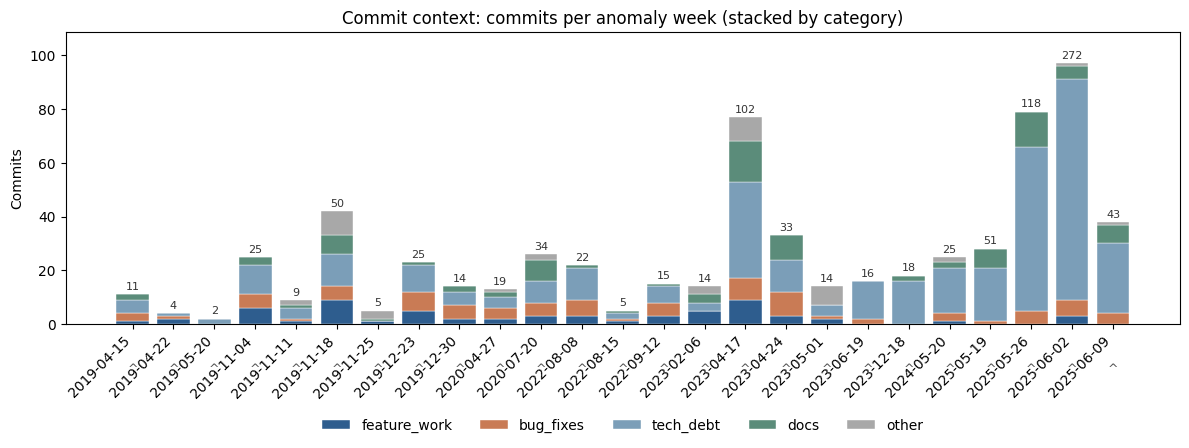

In [14]:
# Simple view of commit_context: per-anomaly-week commit volume stacked by
# high-level commit category (feature_work / bug_fixes / tech_debt / docs / other).
# Category counts come from commit_typeclass_per_week (same week_start key).
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path(".")

CATEGORY_COLORS = {
    "feature_work": "#2E5D8E",
    "bug_fixes":    "#C97B55",
    "tech_debt":    "#7B9EB8",
    "docs":         "#5B8C7A",
    "other":        "#A8A8A8",
}

cat_count_cols = [f"cat_{c}_count" for c in CATEGORIES]

ctx = (
    commit_context[["week_start", "anomaly_direction", "commit_event_count"]]
    .merge(
        commit_typeclass_per_week[["week_start", *cat_count_cols]],
        on="week_start",
        how="left",
    )
    .sort_values("week_start")
    .reset_index(drop=True)
)
ctx["week_label"] = pd.to_datetime(ctx["week_start"]).dt.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(12, 4.8))

bottom = np.zeros(len(ctx))
for c in CATEGORIES:
    ax.bar(
        ctx["week_label"], ctx[f"cat_{c}_count"],
        bottom=bottom, color=CATEGORY_COLORS[c], label=c,
        edgecolor="white", linewidth=0.3,
    )
    bottom += ctx[f"cat_{c}_count"].values

ymax = float(bottom.max()) if len(bottom) else 1.0
for i, (x, total) in enumerate(zip(ctx["week_label"], ctx["commit_event_count"])):
    ax.text(
        x, bottom[i] + ymax * 0.01,
        str(int(total)), ha="center", va="bottom",
        fontsize=8, color="#333333",
    )

dir_marker = {"high": "^", "low": "v"}
for x, direction in zip(ctx["week_label"], ctx["anomaly_direction"]):
    m = dir_marker.get(str(direction))
    if m:
        ax.annotate(
            m, xy=(x, 0), xytext=(0, -28),
            textcoords="offset points", ha="center", va="top",
            fontsize=9, color="#555555", annotation_clip=False,
        )

ax.set_ylim(0, ymax * 1.12 if ymax > 0 else 1)
ax.set_ylabel("Commits")
ax.set_title("Commit context: commits per anomaly week (stacked by category)")
ax.tick_params(axis="x", rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.28),
    ncol=len(CATEGORIES), frameon=False,
)

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "commit_context_category_stack.png",
    dpi=150, bbox_inches="tight",
)
plt.show()